# Analysis of uncertainty vs. integrated SNR

This notebook plots the *N-M* percentile range of the 2100 $\theta$ posterior against the cumulative signal to nose ratio (cSNR) in 2100, which I define as

$
  cSNR = \left( \int_{2025}^{2100} \dfrac{g_{t'}}{\bar{f}_{t'}} dt'\right) \sqrt{ \dfrac{75}{\sigma^2_{f_{2\times}} + \sigma^{2}_{\varepsilon}} \dfrac{1 - \rho}{1 + \rho} }
$

# Step 0: Config, dependent functions, and other setup

In [9]:
import os
import gc
import logging

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

from matplotlib.lines import Line2D
from pathlib import Path
from argparse import Namespace
from datatree import open_datatree
from scipy.stats import describe
from var_assim.plotting.presets import get_presets
from var_assim.plotting.filtering import filter_by_cost_ratio_memeff
from var_assim.emis import EmissionsBaseline
from var_assim.plotting.utils import make_figure_filename
from var_assim.config import DATA_DIR_ABS, PRIOR_PATH, NOISE_PATH, WINDOW_PATH, TRUTH_PATH, FIGS_DIR
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)-8s | %(message)s",
                    datefmt="%H:%M:%S")

logs = logging.getLogger('dummy')
logs.info("Logger made!")

14:24:09 | INFO     | Logger made!


In [3]:
# this is new and right (ง'̀-'́)ง
def get_angle(a1, a2, b1, b2, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

def get_stats(x, PLO=5, PHI=95):
    return np.nanmean(x), np.nanmedian(x), np.nanpercentile(x, PHI) - np.percentile(x, PLO)

In [4]:
def get_cumulative_snr(t, e, F2x_avg, F2x_std, noise_var, auto_corr, reg_noise):
    co2 = F2x_avg * np.log(e.conc['CO2'][t] / e.conc["CO2"][0])
    geo = np.abs(e.forcing['geo'][t])

    upper = np.cumsum(geo / co2)[-1]

    param_piece = (F2x_std**2 / 75.) * np.mean(
        (np.abs(e.forcing['geo'][1:t])) / (F2x_avg * np.log(e.conc['CO2'][1:t] / e.conc["CO2"][0]))**2
    )**2

    int_var_piece = (noise_var / 75.) * ((1 + auto_corr) / (1 - auto_corr))

    reg_piece = np.sum(np.array(reg_noise)**2 / 75.)

    denom = np.sqrt(param_piece + int_var_piece + reg_piece)

    snr = upper / denom
    # snr *= correction

    #lower = [(np.cumsum((F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])))**2 
    #+ samp_std**2 * t * ((1 + auto_corr) / (1 - auto_corr))
    #)[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #+ (samp_std / np.sqrt(1 - auto_corr**2)) * np.cumsum(
    #    (f * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]) / (l + g * ep) )))[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #lower = np.mean(lower)

    # print(upper, lower)

    return snr

# Step 1: Import data, filter, make angle lists, and dispose

In [5]:
# simulation config
cwd = os.getcwd()

# file attributes we need to import
ssps = ['ssp245', 'ssp585']
DEGpDECs = ['0.1', '0.2']
noise_models = ['Noiseless', 'AR(0)', 'AR(1)']
anglesf = ['5', '11', '15', '21', '30', '35']
models = ['pco2geowc_reg', 'pco2geowc_reg', 'pco2geowc_reg', 'pco2geowc_nn']

# static simulation attributes 
TMIN = 2023
ECS = 3.0  # NOTE: EVENTUALLY I'LL DO THIS FOR MULTIPLE ECS VALUES
F2x_avg = 4.58
NYRSRAMP = 50
windowing_config = 'ws_gradual'
Nens = 1000

INT_VAR_STD = 0.27  # from proistosescu and huybers
AUTO_CORR = 0.2  # AR(1) param
REG_STD = [0.35, 0.3]  # regional noise for regions 1 and 2

# dictionary of noise model characteristics
noise_model_chars = {
    'Noiseless': {
        'int_var_std': 0,
        'auto_corr': 0,
        'reg_stds': [0, 0]
    },
    'AR(0)': {
        'int_var_std': INT_VAR_STD,
        'auto_corr': 0,
        'reg_stds': [0, 0]
    },
    'AR(1)': {
        'int_var_std': INT_VAR_STD,
        'auto_corr': AUTO_CORR,
        'reg_stds': [0, 0]
    }
}

In [6]:
dt_meta = open_datatree(
    DATA_DIR_ABS / 'output' / models[0] / 
    f"var-assim-output_{ssps[0]}_{models[0]}_{windowing_config}_AR1+reg_TMIN{TMIN}_THETA{anglesf[0]}_ECS{ECS}_DEGpDEC{DEGpDECs[0]}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc",
    engine='netcdf4')

In [7]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist']
all_vars = [x for x in dt_meta['2025'].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
THRESHOLD = 1e-2  # cost function ratio filtering

# cleanup
for node in dt_meta.subtree:
    if node.ds is not None:
        node.ds.close()

del dt_meta
gc.collect()

476

In [8]:
data_dir_root = DATA_DIR_ABS / "output"
file_prefix = 'var-assim-output'
simulation_dict = {}

wind_ = '2100'
PLO = 5  # lower percentile for percentile range
PHI = 95  # higher percentile for percentile range

for ssp in ssps:
    logs.info(f"🏭 Processing {ssp}...")
    simulation_dict[ssp] = {}
    for DEGpDEC in DEGpDECs:
        logs.info(f"    📐 Processing DEGpDEC {DEGpDEC}...")
        simulation_dict[ssp][DEGpDEC] = {}
        
        for noise_model in noise_models:
            logs.info(f"        🔊 Processing noise model {noise_model}...")
            simulation_dict[ssp][DEGpDEC][noise_model] = {}
            if noise_model == 'Noiseless':
                model = 'pco2geowc_nn'

            else:
                model = 'pco2geowc_reg'

            for angles in anglesf:
                logs.info(f"            📐 Processing angle = {angles}...")
                simulation_dict[ssp][DEGpDEC][noise_model][angles] = {}

                if noise_model == 'AR(0)':
                    noise_m = 'AR0'
                    AR = 0
                    reg = True
                    filename = f'{data_dir_root}/{model}/{file_prefix}_{ssp}_{model}_{windowing_config}_AR0+reg_TMIN{TMIN}_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc'

                elif noise_model == 'AR(1)':
                    noise_m = 'AR1'
                    AR = 1
                    reg = True
                    filename = f'{data_dir_root}/{model}/{file_prefix}_{ssp}_{model}_{windowing_config}_AR1+reg_TMIN{TMIN}_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc'
                
                else:  # no noise
                    noise_m = 'nn'
                    AR = None
                    reg = False
                    filename = f'{data_dir_root}/{model}/{file_prefix}_{ssp}_{model}_{windowing_config}_nn_TMIN{TMIN}_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc'

                dt = open_datatree(filename, engine='netcdf4', drop_variables=dropped_vars)

                ds = filter_by_cost_ratio_memeff(dt[wind_].ds, threshold=THRESHOLD)

                # compute prior uncertainty 
                prior_a1 = ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
                prior_b1 = ds.controls_hist.sel(vari='BETA_R1', iter=0).values
                prior_a2 = ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
                prior_b2 = ds.controls_hist.sel(vari='BETA_R2', iter=0).values
                prior_l = ds.controls_hist.sel(vari='L', iter=0).values
                prior_g = ds.controls_hist.sel(vari='G', iter=0).values
                prior_eps = ds.controls_hist.sel(vari='EPS', iter=0).values

                angles_prior = np.zeros(Nens)
                for i in range(Nens):
                    angles_prior[i] = get_angle(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])
                logs.info(f"                ✅ Prior angles computed!")

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['prior'] = angles_prior
                simulation_dict[ssp][DEGpDEC][noise_model][angles][f'prior_{PLO}-{PHI}_range'] = np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)

                # compute posterior uncertainty 
                tmp_a1 = ds.controls.sel(vari='ALPHA_R1').values
                tmp_a2 = ds.controls.sel(vari='ALPHA_R2').values
                tmp_b1 = ds.controls.sel(vari='BETA_R1').values
                tmp_b2 = ds.controls.sel(vari='BETA_R2').values
                tmp_l = ds.controls.sel(vari='L').values
                tmp_g = ds.controls.sel(vari='G').values
                tmp_eps = ds.controls.sel(vari='EPS').values

                angles_post = np.zeros(Nens)
                for i in range(Nens):
                    angles_post[i] = get_angle(tmp_a1[i], tmp_a2[i], tmp_b1[i], tmp_b2[i], tmp_l[i], tmp_eps[i], tmp_g[i])
                logs.info(f"                ✅ Posterior angles computed!")

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['post'] = angles_post
                simulation_dict[ssp][DEGpDEC][noise_model][angles][f'post_{PLO}-{PHI}_range'] = np.nanpercentile(angles_post, PHI) - np.nanpercentile(angles_post, PLO)

                cli_args = Namespace(
                    model=model,
                    scenario=ssp,
                    noise_model=noise_m,
                    tmin=TMIN,
                    theta=float(angles),
                    AR=AR,
                    ecs=ECS,
                    deg_p_dec=float(DEGpDEC),
                    nyrsramp=NYRSRAMP,
                    n_ens=Nens,
                    reg_noise=reg,
                    windowing=windowing_config
                )

                # setup data classes
                Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
                Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
                Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)
                Truth = ClimateModelTruth.from_cli_and_yaml(cli_args, TRUTH_PATH)

                # make emissions baseline
                e = EmissionsBaseline(logs, cli_args, TMIN, 2100,
                                      geo=True, Prior=Prior, Truth=Truth,
                                      T_START=TMIN, T_END=TMIN + NYRSRAMP, print_level=1)

                # compute cumulative SNR
                cSNR = get_cumulative_snr(2100 - int(TMIN), e,
                                         Prior.F1_CO2_CEN,
                                         Prior.F1_CO2_STD,
                                         noise_model_chars[noise_model]['int_var_std']**2,
                                         noise_model_chars[noise_model]['auto_corr'],
                                         noise_model_chars[noise_model]['reg_stds'])                    

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['cSNR'] = cSNR

                # cleanup
                for node in dt.subtree:
                    if node.ds is not None:
                        node.ds.close()

                del dt
                gc.collect()
                logs.info(f"                🚮 Trash taken out, restarting process...")


14:24:12 | INFO     | 🏭 Processing ssp245...
14:24:12 | INFO     |     📐 Processing DEGpDEC 0.1...
14:24:12 | INFO     |         🔊 Processing noise model Noiseless...
14:24:12 | INFO     |             📐 Processing angle = 5...
14:24:14 | INFO     |                 ✅ Prior angles computed!
14:24:14 | INFO     |                 ✅ Posterior angles computed!
14:24:16 | INFO     |     > Emissions baseline for ssp245 created
14:24:16 | INFO     |                 🚮 Trash taken out, restarting process...
14:24:16 | INFO     |             📐 Processing angle = 11...
14:24:18 | INFO     |                 ✅ Prior angles computed!
14:24:18 | INFO     |                 ✅ Posterior angles computed!
14:24:18 | INFO     |     > Emissions baseline for ssp245 created
14:24:19 | INFO     |                 🚮 Trash taken out, restarting process...
14:24:19 | INFO     |             📐 Processing angle = 15...
14:24:21 | INFO     |                 ✅ Prior angles computed!
14:24:21 | INFO     |                 

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/notebooks/figs/2026-6-29-unc_vs_csnr.png!


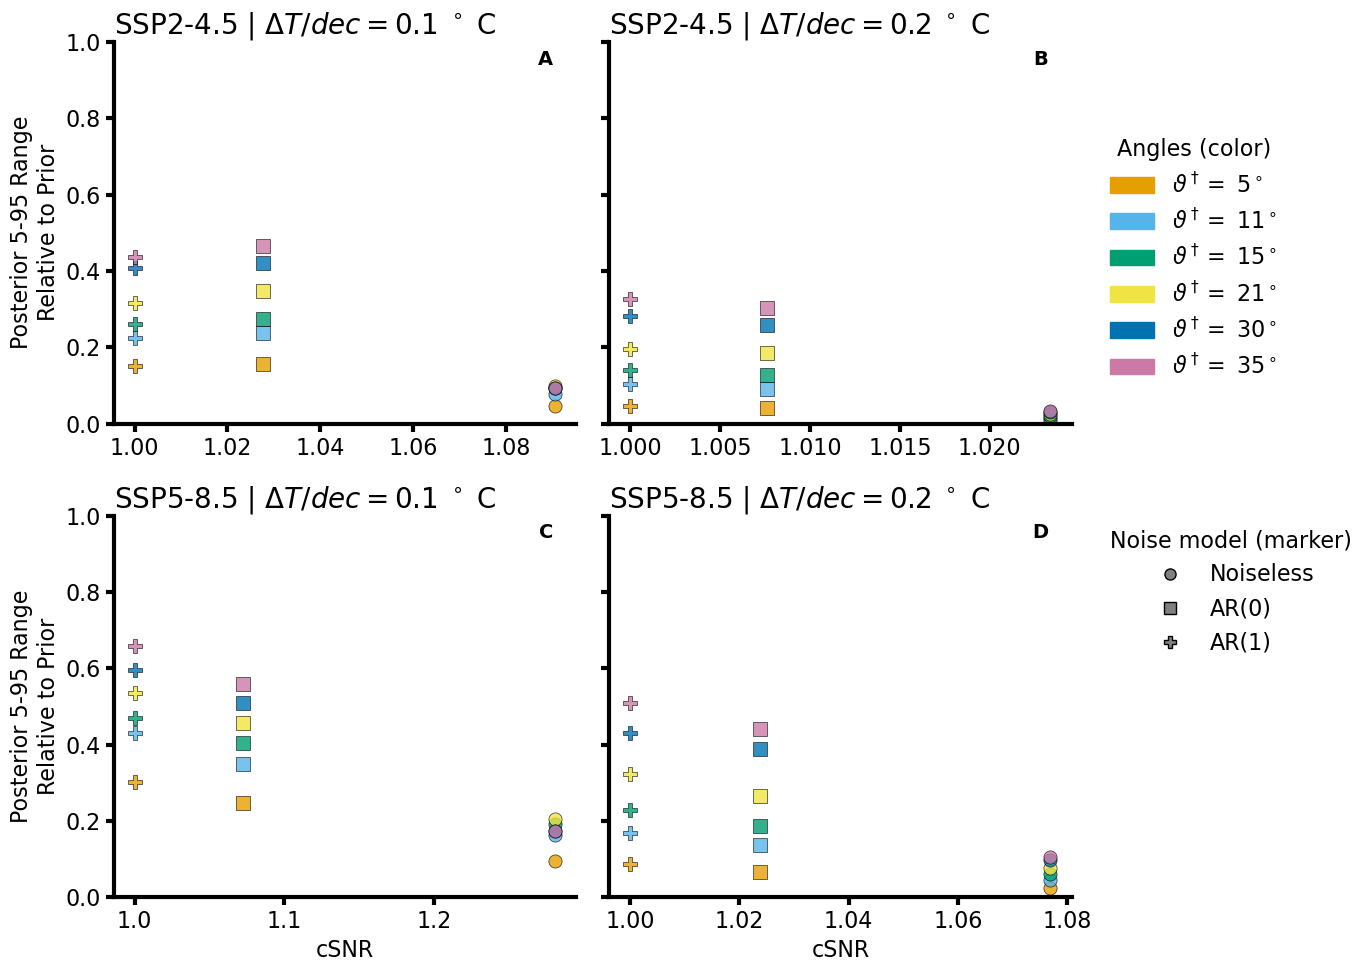

In [31]:
# prepare color and marker lists from presets (keeps notebook's styling)
plot_presets, _ = get_presets(markers=True)
prop_cycle = plot_presets['axes.prop_cycle']
by_key = prop_cycle.by_key()
colors = by_key.get('color', [])
markers = by_key.get('marker', [])
angles_list = anglesf 
noise_list = noise_models 

# mapping from angle string to color (cycle if needed)
angle_to_color = {a: colors[(i+1) % len(colors)] for i, a in enumerate(angles_list[:-1])}
angle_to_color[angles_list[-1]] = colors[-1]
# mapping noise model to marker (cycle if needed)
noise_to_marker = {n: markers[i % len(markers)] for i, n in enumerate(noise_list)}

# create 2x2 grid: rows by ssp, cols by DEGpDEC (or vice versa)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.reshape(2, 2)
for i, j in zip(range(2), range(2)):
    axs[i, j].set_ylim((0, 1))

ssp_order = ssps  # ['ssp245','ssp585']
deg_order = DEGpDECs  # ['0.1','0.2']
ssp_titles = ['SSP2-4.5', 'SSP5-8.5']

for i_ssp, ssp in enumerate(ssp_order):
    for j_deg, deg in enumerate(deg_order):
        ax = axs[i_ssp, j_deg]
        ax.set_title(f'{ssp_titles[i_ssp]} | $\Delta T / dec = ${deg} $^\circ$ C')
        if i_ssp == 1:
            ax.set_xlabel('cSNR')
        if j_deg == 0:
            ax.set_ylabel('Posterior 5-95 Range\nRelative to Prior')

        # collect plotted points for legend handles
        for noise in noise_list:
            # some angle/noise combinations may be missing (e.g., 33 with AR(0))
            for ang in angles_list:
                try:
                    prior_range = simulation_dict[ssp][deg][noise][ang][f'prior_{PLO}-{PHI}_range']
                    post_range = simulation_dict[ssp][deg][noise][ang][f'post_{PLO}-{PHI}_range']
                    csnr = simulation_dict[ssp][deg][noise][ang]['cSNR']
                except Exception:
                    continue

                # guard against zero or nan prior range
                if prior_range == 0 or np.isnan(prior_range):
                    ratio = np.nan
                else:
                    ratio = post_range / prior_range

                ax.scatter(csnr/simulation_dict[ssp][deg]['AR(1)']['5']['cSNR'], ratio, color=angle_to_color[ang], marker=noise_to_marker[noise], s=90, edgecolors='k', linewidths=0.5, alpha=0.8)

# build legend: angles (colors) and noise models (markers)
angle_handles = [mpatches.Patch(color=angle_to_color[a], label=r'$\vartheta^\dagger =$ {}$^\circ$'.format(a)) for a in angles_list]
noise_handles = [Line2D([0], [0], marker=noise_to_marker[n], color='w', label=n, markerfacecolor='gray', markersize=8, markeredgecolor='k') for n in noise_list]

#for ax in axs.flatten():
#    ax.set_ylim((0, 1))

# place legends outside the axes to avoid overlap
axs[0,1].legend(handles=angle_handles, title='Angles (color)', bbox_to_anchor=(1.04, 0.8), loc='upper left')
axs[1,1].legend(handles=noise_handles, title='Noise model (marker)', bbox_to_anchor=(1.04, 0.8), loc='center left')

labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

if SAVE_FIGS:
    filename = make_figure_filename('unc_vs_csnr', outdir=FIGS_DIR / "results")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {basefile + 'unc_vs_csnr.png'}!")

plt.tight_layout()
plt.show()

## With Green -> Yellow -> Red colormap

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/figs/results/2026-06-29-unc_vs_csnr_sequential.png!


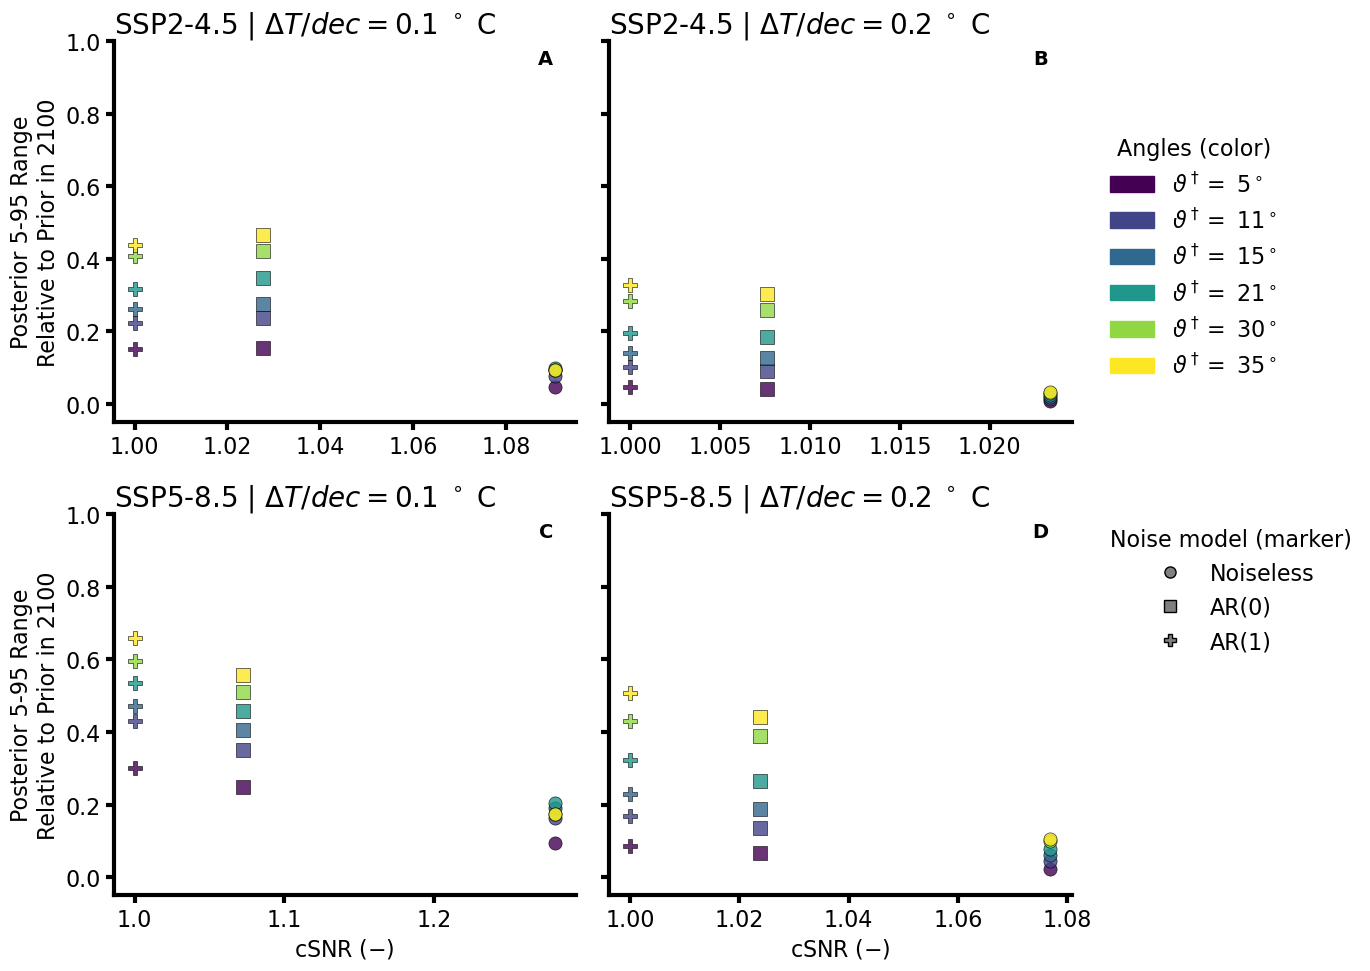

In [28]:
# prepare color and marker lists from presets
plot_presets, _ = get_presets(markers=True)
prop_cycle = plot_presets['axes.prop_cycle']
by_key = prop_cycle.by_key()
markers = by_key.get('marker', [])

angles_list = anglesf
noise_list = noise_models

# --- Sequential colormap: low angle (good) = green, high angle (bad) = red ---
angles_numeric = np.array([float(a) for a in angles_list])

cmap = plt.get_cmap("viridis")
norm = mcolors.Normalize(
    vmin=angles_numeric.min(),
    vmax=angles_numeric.max()
)

angle_to_color = {
    a: cmap(norm(float(a)))
    for a in angles_list
}

# mapping noise model to marker (cycle if needed)
noise_to_marker = {
    n: markers[i % len(markers)]
    for i, n in enumerate(noise_list)
}

# create 2x2 grid: rows by ssp, cols by DEGpDEC (or vice versa)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.reshape(2, 2)

ssp_order = ssps  # ['ssp245','ssp585']
deg_order = DEGpDECs  # ['0.1','0.2']
ssp_titles = ['SSP2-4.5', 'SSP5-8.5']

for i_ssp, ssp in enumerate(ssp_order):
    for j_deg, deg in enumerate(deg_order):
        ax = axs[i_ssp, j_deg]
        ax.set_title(f'{ssp_titles[i_ssp]} | $\Delta T / dec = ${deg} $^\circ$ C')
        if i_ssp == 1:
            ax.set_xlabel(r'cSNR ($-$)')
        if j_deg == 0:
            ax.set_ylabel('Posterior 5-95 Range\nRelative to Prior in 2100')

        # collect plotted points for legend handles
        for noise in noise_list:
            # some angle/noise combinations may be missing (e.g., 33 with AR(0))
            for ang in angles_list:
                try:
                    prior_range = simulation_dict[ssp][deg][noise][ang][f'prior_{PLO}-{PHI}_range']
                    post_range = simulation_dict[ssp][deg][noise][ang][f'post_{PLO}-{PHI}_range']
                    csnr = simulation_dict[ssp][deg][noise][ang]['cSNR']
                except Exception:
                    continue

                # guard against zero or nan prior range
                if prior_range == 0 or np.isnan(prior_range):
                    ratio = np.nan
                else:
                    ratio = post_range / prior_range

                ax.scatter(csnr/simulation_dict[ssp][deg]['AR(1)']['5']['cSNR'], ratio, color=angle_to_color[ang], marker=noise_to_marker[noise], s=90, edgecolors='k', linewidths=0.5, alpha=0.8)

# build legend: angles (colors) and noise models (markers)
angle_handles = [
    mpatches.Patch(
        color=angle_to_color[a],
        label=r'$\vartheta^\dagger =$ {}$^\circ$'.format(a)
    )
    for a in angles_list
]
noise_handles = [Line2D([0], [0], marker=noise_to_marker[n], color='w', label=n, markerfacecolor='gray', markersize=8, markeredgecolor='k') for n in noise_list]

for ax in axs.flatten():
    ax.set_ylim((-0.05, 1))

# place legends outside the axes to avoid overlap
axs[0,1].legend(
    handles=angle_handles,
    title='Angles (color)',
    bbox_to_anchor=(1.04, 0.8),
    loc='upper left'
)
axs[1,1].legend(handles=noise_handles, title='Noise model (marker)', bbox_to_anchor=(1.04, 0.8), loc='center left')

labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

if SAVE_FIGS:
    filename = make_figure_filename('unc_vs_csnr_sequential', outdir=FIGS_DIR / "results")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {filename}!")

plt.tight_layout()
plt.show()

## Points randomly moved to prevent overlap

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-3-4-unc_vs_csnr_scattered.png!


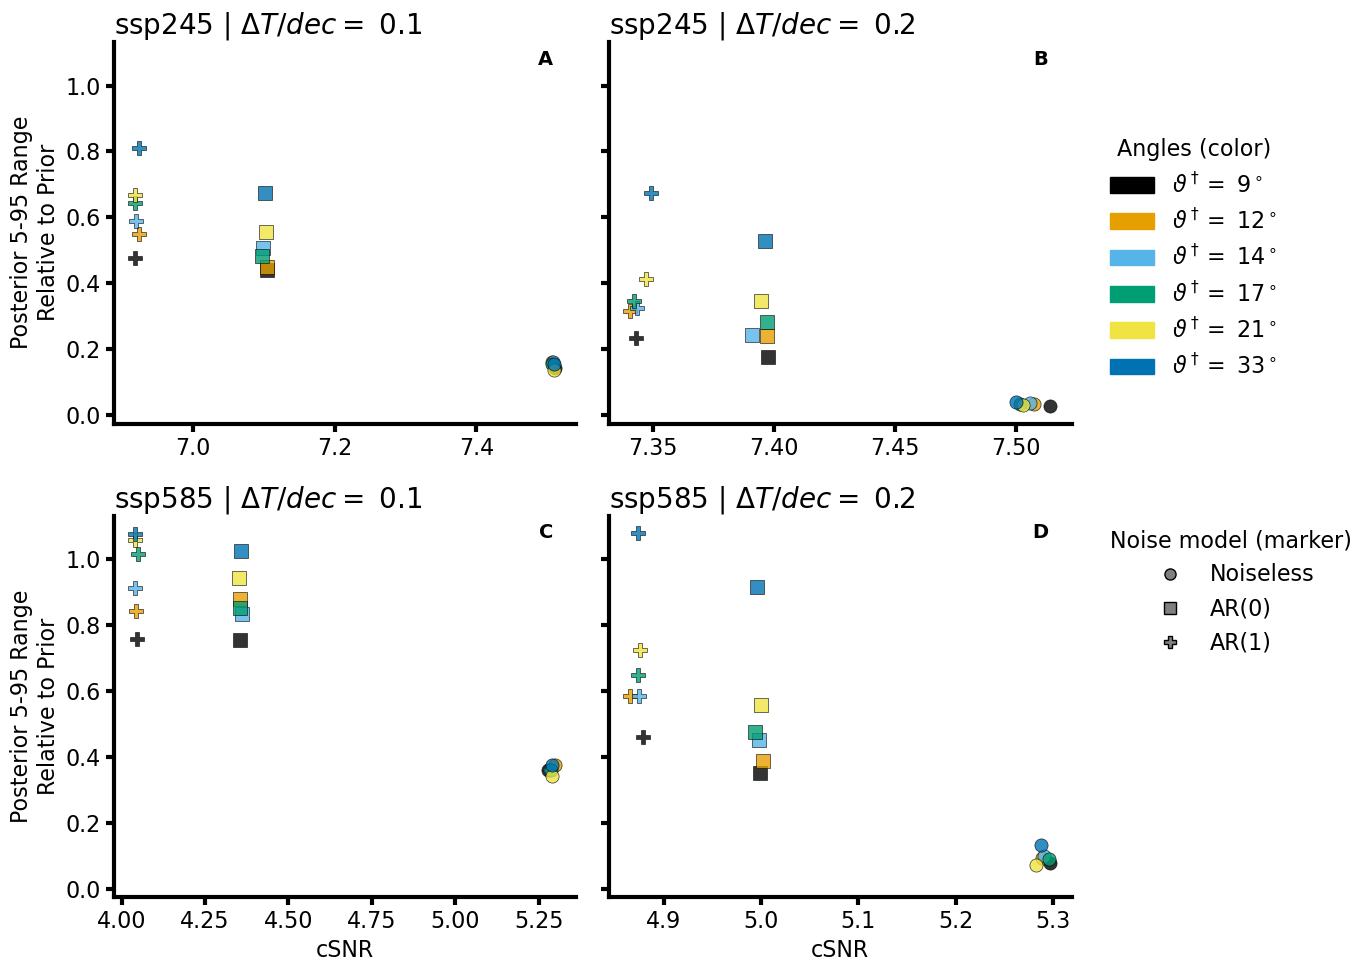

In [13]:
import numpy as np
# Plot ratio of posterior/prior 5-95 percentile range vs cSNR
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# prepare color and marker lists from presets (keeps notebook's styling)
plot_presets, _ = get_presets(markers=True)
prop_cycle = plot_presets['axes.prop_cycle']
by_key = prop_cycle.by_key()
colors = by_key.get('color', [])
markers = by_key.get('marker', [])
angles_list = anglesf  # ['9','12','14','17','21','33'] from above
noise_list = noise_models  # ['no_noise','AR(0)','AR(1)']

# mapping from angle string to color (cycle if needed)
angle_to_color = {a: colors[i % len(colors)] for i, a in enumerate(angles_list)}
# mapping noise model to marker (cycle if needed)
noise_to_marker = {n: markers[i % len(markers)] for i, n in enumerate(noise_list)}

# create 2x2 grid: rows by ssp, cols by DEGpDEC (or vice versa)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.reshape(2, 2)
ssp_order = ssps  # ['ssp245','ssp585']
deg_order = DEGpDECs  # ['0.1','0.2']

for i_ssp, ssp in enumerate(ssp_order):
    for j_deg, deg in enumerate(deg_order):
        ax = axs[i_ssp, j_deg]
        ax.set_title(f'{ssp} | $\Delta T / dec = $ {deg}')
        if i_ssp == 1:
            ax.set_xlabel('cSNR')
        if j_deg == 0:
            ax.set_ylabel('Posterior 5-95 Range\nRelative to Prior')

        # collect plotted points for legend handles
        for noise in noise_list:
            # some angle/noise combinations may be missing (e.g., 33 with AR(0))
            for ang in angles_list:
                try:
                    prior_range = simulation_dict[ssp][deg][noise][ang][f'prior_{PLO}-{PHI}_range']
                    post_range = simulation_dict[ssp][deg][noise][ang][f'post_{PLO}-{PHI}_range']
                    csnr = simulation_dict[ssp][deg][noise][ang]['cSNR']
                except Exception:
                    continue

                # guard against zero or nan prior range
                if prior_range == 0 or np.isnan(prior_range):
                    ratio = np.nan
                else:
                    ratio = post_range / prior_range

                ax.scatter(csnr + np.random.normal(0, 0.005), ratio, color=angle_to_color[ang], marker=noise_to_marker[noise], s=90, edgecolors='k', linewidths=0.5, alpha=0.8)

# build legend: angles (colors) and noise models (markers)
angle_handles = [mpatches.Patch(color=angle_to_color[a], label=r'$\vartheta^\dagger =$ {}$^\circ$'.format(a)) for a in angles_list]
noise_handles = [Line2D([0], [0], marker=noise_to_marker[n], color='w', label=n, markerfacecolor='gray', markersize=8, markeredgecolor='k') for n in noise_list]

#for ax in axs.flatten():
#    ax.set_ylim((0, 1))

# place legends outside the axes to avoid overlap
axs[0,1].legend(handles=angle_handles, title='Angles (color)', bbox_to_anchor=(1.04, 0.8), loc='upper left')
axs[1,1].legend(handles=noise_handles, title='Noise model (marker)', bbox_to_anchor=(1.04, 0.8), loc='center left')


labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
    
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(basefile + 'unc_vs_csnr_scattered.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {basefile + 'unc_vs_csnr_scattered.png'}!")
plt.show()